## Simulation of DTShallowVar Model - (Dual Trap: Variable-Density Shallow Trap with De-Trapping, Deep Non-Radiative Trap)

In [1]:
from globalfit_functions import *
import matplotlib.pyplot as plt

#### Define Simulation Parameters

In [2]:
#Time between 0 and 100 microseconds, logarithmically spaced
time = (jnp.logspace(0, np.log10(100001), 1000))-1

#Initial Carrier Densities
n0s = [1e14, 1e15, 1e16, 1e17, 1e18]

#Rate Constants
krad = 1e-19 #Radiative (cm^3 ns^-1)
beta_n_t1 = 1e-17 #Shallow Trap Capture (cm^3 ns^-1)
e_n_t1 = 1e-3 #Shallow Trap Emission / De-Trapping (ns^-1)
N_t1 = 1e15 #Shallow Trap Density
beta_n_t2 = 1e-4 #Deep Trap Capture (ns^-1)
bkg = 1e-5 #Background Signal

time_label = 'Time (ns)'
qfls_label = 'QFLS (eV)'
PL_label = 'PL (a.u.)'
diff_decay_label = fr'$\tau_{{diff}}$ (s)'
diff_const_label = fr'$k_{{diff}}$ ($cm^{{3}}s^{{-1}})$'


#### Simulate TRPL Decays and Differential Transformations

Simulating for n0 = 1.00e+14
Simulating for n0 = 1.00e+15
Simulating for n0 = 1.00e+16
Simulating for n0 = 1.00e+17
Simulating for n0 = 1.00e+18


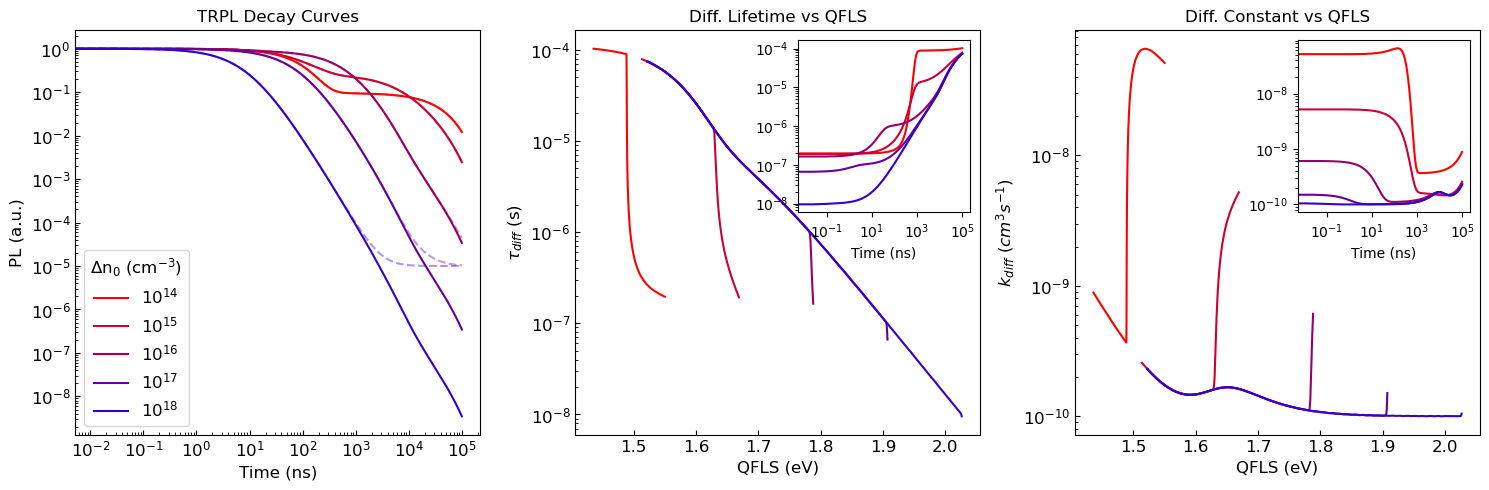

In [3]:
fig, ax = plt.subplots(1,3 , figsize=(15,5))
ax_inset_1 = ax[1].inset_axes([0.55, 0.55, 0.425, 0.425])
ax_inset_2 = ax[2].inset_axes([0.55, 0.55, 0.425, 0.425])
for i, n in enumerate(n0s):
    print(f'Simulating for n0 = {n:.2e}')
    color = colorFader('red', 'blue', factor=float(i)/len(n0s))

    trpl, n_e, n_p, n_t1 = TRPL_DTShallowVar(time, krad, beta_n_t1, e_n_t1, N_t1, beta_n_t2, n, 0)
    trpl_with_bkg = TRPL_DTShallowVar(time, krad, beta_n_t1, e_n_t1, N_t1, beta_n_t2, n, bkg)[0]
    trpl = 10**trpl
    trpl_with_bkg = 10**trpl_with_bkg
    ax[0].loglog(time, trpl_with_bkg/trpl_with_bkg[0], color=color, alpha=0.4, linestyle='dashed')
    ax[0].loglog(time, trpl/trpl[0], color=color, label =f'10$^{{{int(np.log10(n))}}}$')

    tau = diff_lifetime(time, trpl)
    d = diff_constant(time, trpl, n)
    qfls = relative_QFLS(trpl, n0=n, n0_max=n0s[0], eg=1.55)

    ax[1].semilogy(qfls, tau, color=color)
    ax_inset_1.loglog(time, tau, color=color)
    ax[2].semilogy(qfls, d, color=color)
    ax_inset_2.loglog(time, d, color=color)

ax[0].set_xlabel(time_label, fontsize='large')
ax[0].set_ylabel(PL_label, fontsize='large')
ax[0].set_title('TRPL Decay Curves')
ax[0].legend(title=fr'$\Delta$n$_0$ (cm$^{{-3}}$)', loc = 'lower left', fontsize='large', title_fontsize='large')
ax[1].set_xlabel(qfls_label, fontsize='large')
ax[1].set_ylabel(diff_decay_label, fontsize='large')
ax[1].set_title('Diff. Lifetime vs QFLS', fontsize='large')
ax_inset_1.set_xlabel(time_label, fontsize='medium')
ax_inset_2.set_xlabel(time_label, fontsize='medium')
ax[2].set_xlabel(qfls_label, fontsize='large')
ax[2].set_ylabel(diff_const_label, fontsize='large')
ax[2].set_title('Diff. Constant vs QFLS', fontsize='large')
ax[0].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[1].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[2].tick_params(axis='both', which='both', labelsize='large', direction='in')

fig.tight_layout()

#### Simulate Charge Carriers

<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
C:\Users\barne\AppData\Local\Temp\ipykernel_10144\2188966357.py:15: SyntaxWarning: invalid escape sequence '\D'
  ax[i//2].set_title(f'Carrier Densities for $\Delta$n$_0$ = 10$^{{{int(np.log10(n))}}}$ cm$^{{-3}}$', fontsize='x-large')


Simulating for n0 = 1.00e+14
Simulating for n0 = 1.00e+16
Simulating for n0 = 1.00e+18


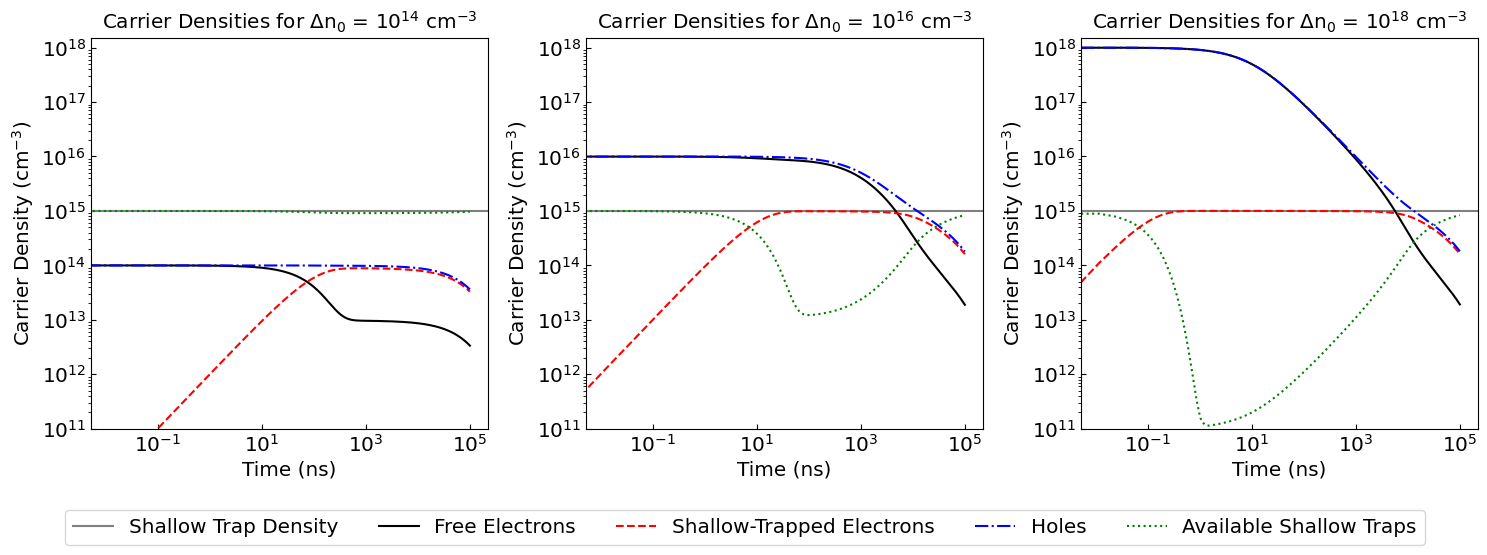

In [4]:
fig, ax = plt.subplots(1,3 , figsize=(15,5))
for i, n in enumerate(n0s):
    if i % 2 == 0:
        print(f'Simulating for n0 = {n:.2e}')

        trpl, n_e, n_p, n_t1 = TRPL_DTShallowVar(time, krad, beta_n_t1, e_n_t1, N_t1, beta_n_t2, n, 0)
        available_traps = N_t1 - n_t1
        ax[i//2].axhline(N_t1, color='grey', label='Shallow Trap Density')
        ax[i//2].loglog(time, n_e, color='black', linestyle='solid')
        ax[i//2].loglog(time, n_t1, color='red', linestyle='dashed')
        ax[i//2].loglog(time, n_p, color='blue', linestyle='dashdot')
        ax[i//2].loglog(time, available_traps, color='green', linestyle='dotted')
        ax[i//2].set_xlabel(time_label, fontsize='x-large')
        ax[i//2].set_ylabel(r'Carrier Density (cm$^{-3}$)', fontsize='x-large')
        ax[i//2].set_title(f'Carrier Densities for $\Delta$n$_0$ = 10$^{{{int(np.log10(n))}}}$ cm$^{{-3}}$', fontsize='x-large')
        ax[i//2].set_ylim(1e11,1.5e18)
        ax[i//2].tick_params(axis='both', which='major', labelsize='x-large', direction='in')
fig.legend(['Shallow Trap Density', 'Free Electrons', 'Shallow-Trapped Electrons', 'Holes', 'Available Shallow Traps'], fontsize='x-large', ncols=5, loc='upper center', bbox_to_anchor=(0.5, -0.01))
fig.tight_layout()

#### Contributions of Each Physical Process

<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
C:\Users\barne\AppData\Local\Temp\ipykernel_10144\1885121785.py:20: SyntaxWarning: invalid escape sequence '\D'
  ax[i//2].set_title(f'Decay Contributions for $\Delta$n$_0$ = 10$^{{{int(np.log10(n))}}}$ cm$^{{-3}}$', fontsize='x-large')


Simulating for n0 = 1.00e+14


C:\Users\barne\AppData\Local\Temp\ipykernel_10144\1885121785.py:23: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[i//2].set_xlim(0,1e5)


Simulating for n0 = 1.00e+16
Simulating for n0 = 1.00e+18


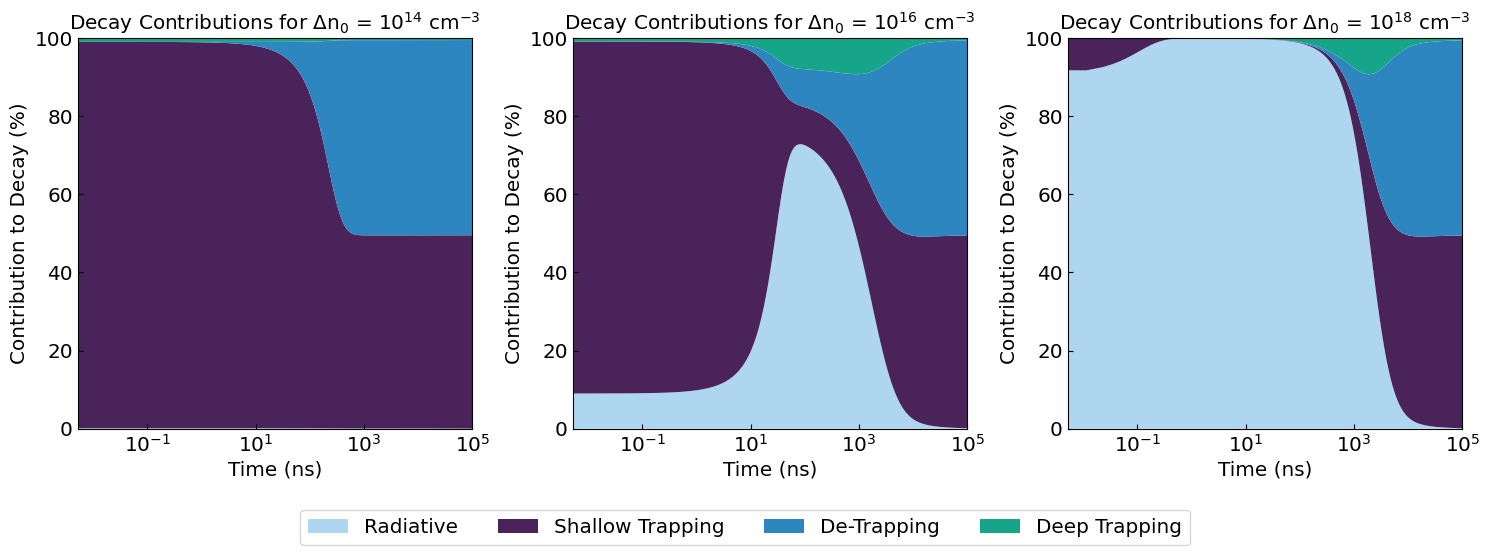

In [5]:
planner2_colors = ['#AED6F1', '#4A235A', '#2E86C1', '#17A589', '#FFDAB9']
fig, ax = plt.subplots(1,3 , figsize=(15,5))
for i, n in enumerate(n0s):
    if i % 2 == 0:
        print(f'Simulating for n0 = {n:.2e}')

        trpl, n_e, n_p, n_t1 = TRPL_DTShallowVar(time, krad, beta_n_t1, e_n_t1, N_t1, beta_n_t2, n, 0)
        radiative = krad * n_e * n_p
        trapping = beta_n_t1 * n_e * (N_t1 - n_t1)
        detrapping = e_n_t1 * n_t1
        deep = beta_n_t2 * n_e

        total = radiative + trapping + detrapping + deep

        radiative_norm, trapping_norm, detrapping_norm, deep_norm = [100*x/total for x in [radiative, trapping, detrapping, deep]]

        ax[i//2].stackplot(time, radiative_norm, trapping_norm, detrapping_norm, deep_norm, colors=planner2_colors, labels=['Radiative', 'Shallow Trapping', 'De-Trapping', 'Deep Trapping'])
        ax[i//2].set_xlabel(time_label, fontsize='x-large')
        ax[i//2].set_ylabel('Contribution to Decay (%)', fontsize='x-large')
        ax[i//2].set_title(f'Decay Contributions for $\Delta$n$_0$ = 10$^{{{int(np.log10(n))}}}$ cm$^{{-3}}$', fontsize='x-large')
        ax[i//2].set_ylim(0,100)
        ax[i//2].set_xscale('log')
        ax[i//2].set_xlim(0,1e5)
        ax[i//2].tick_params(axis='both', which='major', labelsize='x-large', direction='in')
fig.legend(['Radiative', 'Shallow Trapping', 'De-Trapping', 'Deep Trapping'], fontsize='x-large', ncols=4, loc='upper center', bbox_to_anchor=(0.5, -0.01))
fig.tight_layout()

#### Effect of N_t1

Simulating for N_t1 = 1.00e+14
Simulating for N_t1 = 1.00e+15
Simulating for N_t1 = 1.00e+16
Simulating for N_t1 = 1.00e+17


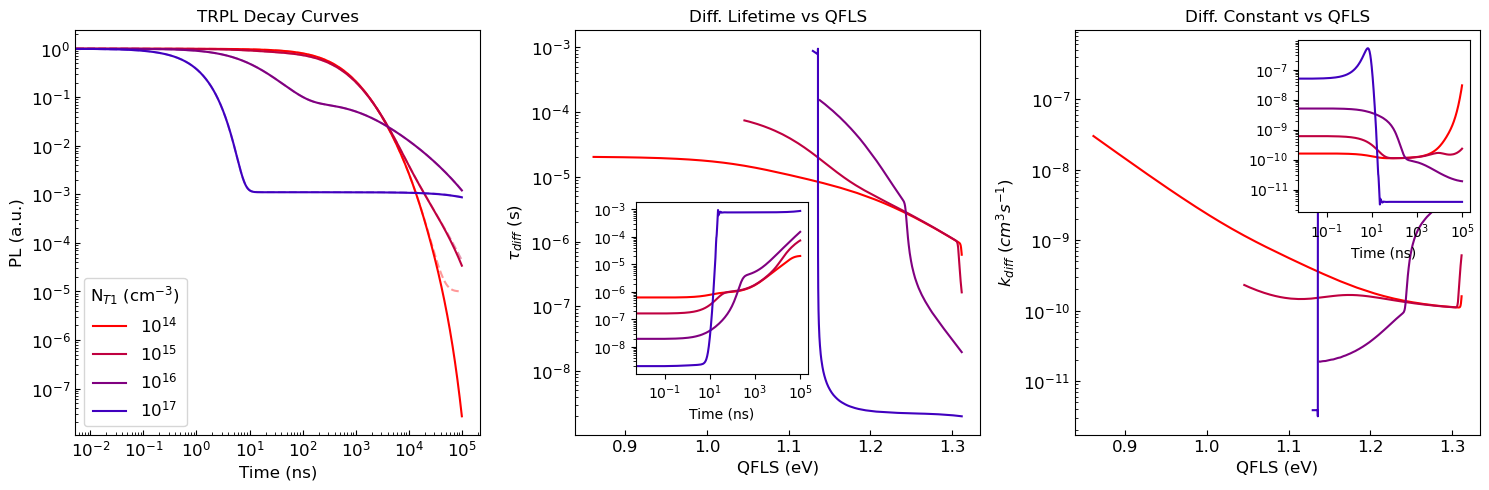

In [6]:
N_t1s = [1e14, 1e15, 1e16, 1e17]
n0 = 1e16
fig, ax = plt.subplots(1,3 , figsize=(15,5))
ax_inset_1 = ax[1].inset_axes([0.15, 0.15, 0.425, 0.425])
ax_inset_2 = ax[2].inset_axes([0.55, 0.55, 0.425, 0.425])
for i, N_t1 in enumerate(N_t1s):
    print(f'Simulating for N_t1 = {N_t1:.2e}')
    color = colorFader('red', 'blue', factor=float(i)/len(N_t1s))

    trpl, n_e, n_p, n_t1 = TRPL_DTShallowVar(time, krad, beta_n_t1, e_n_t1, N_t1, beta_n_t2, n0, 0)
    trpl_with_bkg = TRPL_DTShallowVar(time, krad, beta_n_t1, e_n_t1, N_t1, beta_n_t2, n0, bkg)[0]
    trpl = 10**trpl
    trpl_with_bkg = 10**trpl_with_bkg
    ax[0].loglog(time, trpl_with_bkg/trpl_with_bkg[0], color=color, alpha=0.4, linestyle='dashed')
    ax[0].loglog(time, trpl/trpl[0], color=color, label =f'10$^{{{int(np.log10(N_t1))}}}$')

    tau = diff_lifetime(time, trpl)
    d = diff_constant(time, trpl, n0)
    qfls = relative_QFLS(trpl, n0=n0, n0_max=1e18, eg=1.55)

    ax[1].semilogy(qfls, tau, color=color)
    ax_inset_1.loglog(time, tau, color=color)
    ax[2].semilogy(qfls, d, color=color)
    ax_inset_2.loglog(time, d, color=color)

ax[0].set_xlabel(time_label, fontsize='large')
ax[0].set_ylabel(PL_label, fontsize='large')
ax[0].set_title('TRPL Decay Curves')
ax[0].legend(title=fr'N$_{{T1}}$ (cm$^{{-3}}$)', loc = 'lower left', fontsize='large', title_fontsize='large')
ax[1].set_xlabel(qfls_label, fontsize='large')
ax[1].set_ylabel(diff_decay_label, fontsize='large')
ax[1].set_title('Diff. Lifetime vs QFLS', fontsize='large')
ax_inset_1.set_xlabel(time_label, fontsize='medium')
ax_inset_2.set_xlabel(time_label, fontsize='medium')
ax[2].set_xlabel(qfls_label, fontsize='large')
ax[2].set_ylabel(diff_const_label, fontsize='large')
ax[2].set_title('Diff. Constant vs QFLS', fontsize='large')
ax[0].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[1].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[2].tick_params(axis='both', which='both', labelsize='large', direction='in')

fig.tight_layout()
N_t1 = 1e15 #Reset to the default value

#### Effect of e_n_t1

Simulating for e_n_t1 = 1.00e-02
Simulating for e_n_t1 = 1.00e-03
Simulating for e_n_t1 = 1.00e-04


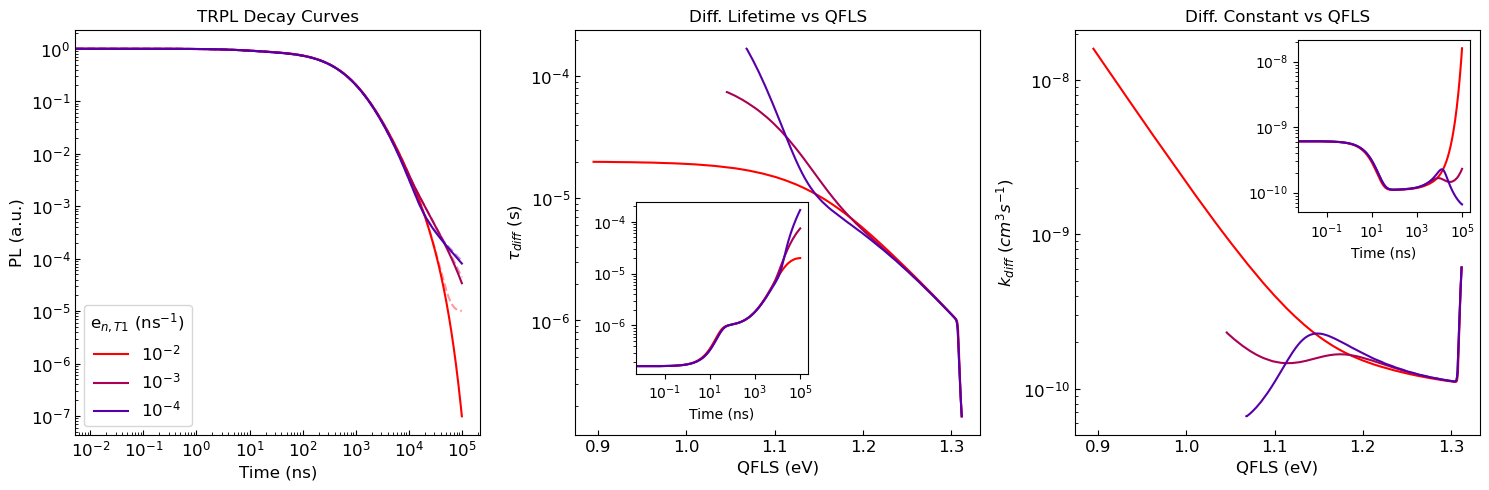

In [7]:
e_n_t1s = [1e-2, 1e-3, 1e-4]
n0 = 1e16
fig, ax = plt.subplots(1,3 , figsize=(15,5))
ax_inset_1 = ax[1].inset_axes([0.15, 0.15, 0.425, 0.425])
ax_inset_2 = ax[2].inset_axes([0.55, 0.55, 0.425, 0.425])
for i, e_n_t1 in enumerate(e_n_t1s):
    print(f'Simulating for e_n_t1 = {e_n_t1:.2e}')
    color = colorFader('red', 'blue', factor=float(i)/len(e_n_t1s))

    trpl, n_e, n_p, n_t1 = TRPL_DTShallowVar(time, krad, beta_n_t1, e_n_t1, N_t1, beta_n_t2, n0, 0)
    trpl_with_bkg = TRPL_DTShallowVar(time, krad, beta_n_t1, e_n_t1, N_t1, beta_n_t2, n0, bkg)[0]
    trpl = 10**trpl
    trpl_with_bkg = 10**trpl_with_bkg
    ax[0].loglog(time, trpl_with_bkg/trpl_with_bkg[0], color=color, alpha=0.4, linestyle='dashed')
    ax[0].loglog(time, trpl/trpl[0], color=color, label =f'10$^{{{int(np.log10(e_n_t1))}}}$')

    tau = diff_lifetime(time, trpl)
    d = diff_constant(time, trpl, n0)
    qfls = relative_QFLS(trpl, n0=n0, n0_max=1e18, eg=1.55)

    ax[1].semilogy(qfls, tau, color=color)
    ax_inset_1.loglog(time, tau, color=color)
    ax[2].semilogy(qfls, d, color=color)
    ax_inset_2.loglog(time, d, color=color)

ax[0].set_xlabel(time_label, fontsize='large')
ax[0].set_ylabel(PL_label, fontsize='large')
ax[0].set_title('TRPL Decay Curves')
ax[0].legend(title=fr'e$_{{n,T1}}$ (ns$^{{-1}}$)', loc = 'lower left', fontsize='large', title_fontsize='large')
ax[1].set_xlabel(qfls_label, fontsize='large')
ax[1].set_ylabel(diff_decay_label, fontsize='large')
ax[1].set_title('Diff. Lifetime vs QFLS', fontsize='large')
ax_inset_1.set_xlabel(time_label, fontsize='medium')
ax_inset_2.set_xlabel(time_label, fontsize='medium')
ax[2].set_xlabel(qfls_label, fontsize='large')
ax[2].set_ylabel(diff_const_label, fontsize='large')
ax[2].set_title('Diff. Constant vs QFLS', fontsize='large')
ax[0].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[1].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[2].tick_params(axis='both', which='both', labelsize='large', direction='in')

fig.tight_layout()
e_n_t1 = 1e-3 #Reset to the default value